# Nonlinear Superposition Toy Model

## Motivation

Elhage et al. (2022), *[Toy Models of Superposition](https://transformer-circuits.pub/2022/toy_model/index.html)*, showed that neural networks can represent **more features than they have neurons** by storing them in superposition: overlapping, near-orthogonal directions in activation space. The phenomenon is tied to sparsity (features that are rarely active can tolerate interference) and is thought to underlie polysemanticity in real language models.

A companion notebook (`linear_superposition_toy_model.ipynb`) studies the **linear** version of this autoencoder and shows rigorously that **superposition cannot occur there**: the only minima of the expected loss are the trivial solutions θ = 0 and θ = π/2, each representing exactly one feature.

This notebook works through the nonlinear case analytically, reproducing and *extending* the phase structure found in Elhage et al.

---

## Model

We study a minimal one-hidden-unit autoencoder with a ReLU output. The network is trained on a dataset $\{x_{Ji}\}$ with sample index $J = 1, \ldots, k$ and feature index $i = 1, 2$. For each sample $x_J \in \mathbb{R}^2$ the forward pass is

$$h_J = w x_J, \qquad x'_J = \mathrm{ReLU}[w^T h_J + b] = \mathrm{ReLU}[w^T w\, x_J + b]$$

with $n = 2$ input features and $m = 1$ latent dimension. The weight vector is parameterised as $w = (\cos\theta,\, \sin\theta)$, so

$$w^T w = \begin{pmatrix} \cos^2\theta & \tfrac{1}{2}\sin 2\theta \\ \tfrac{1}{2}\sin 2\theta & \sin^2\theta \end{pmatrix}.$$

**Input distribution.** Each $x_{Ji}$ is i.i.d.: zero with probability $1 - p_i$, and $\mathrm{Uniform}[0, 1]$ with probability $p_i$. The implied moments are $E[x_{Ji}] = p_i/2$ and $E[x_{Ji}^2] = p_i/3$. Sparsity is controlled by $p_i \ll 1$.

**Loss.** Weighted mean-squared reconstruction error averaged over the dataset:

$$\mathcal{L} = \frac{1}{2k}\sum_{J}\sum_i I_i\,(x_{Ji} - x'_{Ji})^2$$

where $I_i > 0$ are per-feature importance weights. Since $\mathcal{L}$ scales linearly in $I_1$, we can set $I_1 = 1$ without loss of generality; the phase structure depends only on the three parameters $I_2/I_1$, $p_1$, and $p_2$.

---

## Key result

For large batches $\mathcal{L}$ concentrates on its mean $E[\mathcal{L}]$, which is derived **analytically** below. Minimising over $(\theta, b_1, b_2)$ reveals a **three-phase structure**. At leading order in sparsity ($p_i \ll 1$), the phase boundaries depend only on the **effective scarcity** $q_i = I_i p_i$, the product of importance and activity probability. A rare but important feature and a common but unimportant one with the same $q_i$ are interchangeable at this order:

| Phase | Condition (leading order in $p_i$) | Optimal θ | Interpretation |
|:------|:-----------------------------------|:----------|:---------------|
| Feature 1 only | $q_2 < q_1 / 3$ | 0 | Only the more important feature is stored |
| **Superposition** | $q_1/3 < q_2 < 3q_1$ | $3\pi/4$ | Both features are stored in an anti-podal pair |
| Feature 2 only | $q_2 > 3q_1$ | $\pi/2$ | Only the more important feature is stored |

At larger values of $p_i$, the exact phase boundaries depend on $I_2/I_1, p_1, p_2$ separately; the $q_i$-only description breaks down once $p_i$ is no longer negligible. The extent of this breakdown is probed numerically in Sections 3.1 and 3.3. 

The superposition phase at $\theta = 3\pi/4$ is the central finding: **the ReLU nonlinearity enables the network to pack two features into one latent dimension**, exploiting the asymmetry between positive and negative pre-activations.

---

## Contents

| Section | Content |
|:--------|:--------|
| 1. Analytical loss | Closed-form $E[\mathcal{L}]$ derived via auxiliary integrals $F_n, G, \mathcal{F}_n, \mathcal{H}, \mathcal{G}$ |
| 2. MC validation | Analytic loss verified against Monte Carlo at $N = 10^2$--$10^6$ samples |
| 3.1 Collapse test | Agreement fraction: does $q_i = I_i p_i$ fully determine the phase? |
| 3.2 Phase diagram | $\theta^*$ in the $(q_1, q_2)$ plane; leading-order boundaries verified |
| 3.3 Finite-$p$ corrections | Phase boundaries in the $(p_1, p_2)$ plane at fixed $I_2$ |


In [633]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Analytical Loss

Because each $x_{Ji}$ is drawn independently, the expectation $E[\mathcal{L}]$ decomposes into four terms according to which features happen to be active in a given sample:

$$E[\mathcal{L}] = \tfrac{1}{2}(A + B + C + D)$$

**Term A: both features inactive** (probability $(1-p_1)(1-p_2)$): both inputs are zero, so the reconstruction is $x'_i = \mathrm{ReLU}(b_i)$, giving

$$A = (1-p_1)(1-p_2)\sum_i I_i\,\mathrm{ReLU}(b_i)^2.$$

This term drives the biases negative: any $b_i > 0$ incurs a cost even when no feature is present.

**Term B: only feature 1 active** (probability $(1-p_2)\,p_1$): $x_{J1} \sim \mathrm{Unif}[0,1]$, $x_{J2} = 0$. Integrating over $x_{J1}$ yields

$$B = (1-p_2)\,p_1\!\left[I_1\!\left(\tfrac{1}{3} - 2G(\cos^2\theta,\, b_1) + F_2(\cos^2\theta,\, b_1)\right) + I_2\, F_2\!\left(\tfrac{\sin 2\theta}{2},\, b_2\right)\right].$$

**Term C: only feature 2 active** (probability $(1-p_1)\,p_2$): by symmetry ($1 \leftrightarrow 2$, $\cos\theta \leftrightarrow \sin\theta$),

$$C = (1-p_1)\,p_2\!\left[I_1\, F_2\!\left(\tfrac{\sin 2\theta}{2},\, b_1\right) + I_2\!\left(\tfrac{1}{3} - 2G(\sin^2\theta,\, b_2) + F_2(\sin^2\theta,\, b_2)\right)\right].$$

**Term D: both features active** (probability $p_1 p_2$): both $x_{J1}, x_{J2} \sim \mathrm{Unif}[0,1]$, so the pre-activations couple the two inputs. This requires the double integrals $\mathcal{F}_n$, $\mathcal{H}$, $\mathcal{G}$:

$$D = p_1 p_2\!\left[I_1\!\left(\tfrac{1}{3} - 2\mathcal{G}\!\left(\cos^2\theta,\,\tfrac{\sin 2\theta}{2},\, b_1\right) + \mathcal{F}_2\!\left(\cos^2\theta,\,\tfrac{\sin 2\theta}{2},\, b_1\right)\right) + I_2\!\left(\tfrac{1}{3} - 2\mathcal{G}\!\left(\sin^2\theta,\,\tfrac{\sin 2\theta}{2},\, b_2\right) + \mathcal{F}_2\!\left(\sin^2\theta,\,\tfrac{\sin 2\theta}{2},\, b_2\right)\right)\right].$$

---

### Auxiliary integrals

**Single-feature integrals** (used in $B$ and $C$):

$$F_n(\alpha,\beta) \equiv \int_0^1 \mathrm{ReLU}(\alpha x + \beta)^n\, dx = \frac{\mathrm{ReLU}(\alpha+\beta)^{n+1} - \mathrm{ReLU}(\beta)^{n+1}}{\alpha(n+1)}$$

$$G(\alpha,\beta) \equiv \int_0^1 x\,\mathrm{ReLU}(\alpha x + \beta)\,dx = \frac{1}{\alpha}\!\left[\frac{\mathrm{ReLU}(\alpha+\beta)^3 - \mathrm{ReLU}(\beta)^3}{3\alpha} - \beta\,F_1(\alpha,\beta)\right]$$

**Double-feature integrals** (used in $D$): these are obtained by treating the second feature's contribution as a shift in the bias and integrating over $y = x_{J2} \in [0,1]$:

$$\mathcal{F}_n(\alpha,\gamma,\beta) \equiv \int_0^1 F_n(\alpha,\,\gamma y + \beta)\,dy = \frac{\mathrm{ReLU}(\alpha+\gamma+\beta)^{n+2} - \mathrm{ReLU}(\gamma+\beta)^{n+2} - \mathrm{ReLU}(\alpha+\beta)^{n+2} + \mathrm{ReLU}(\beta)^{n+2}}{\alpha\gamma(n+1)(n+2)}$$

$$\mathcal{H}(\alpha,\gamma,\beta) \equiv \int_0^1 y\,F_1(\alpha,\,\gamma y+\beta)\,dy = \frac{\mathrm{ReLU}(\alpha+\gamma+\beta)^3-\mathrm{ReLU}(\gamma+\beta)^3}{6\alpha\gamma} - \frac{\mathrm{ReLU}(\alpha+\gamma+\beta)^4 - \mathrm{ReLU}(\alpha+\beta)^4 - \mathrm{ReLU}(\gamma+\beta)^4 + \mathrm{ReLU}(\beta)^4}{24\alpha\gamma^2}$$

$$\mathcal{G}(\alpha,\gamma,\beta) \equiv \int_0^1 G(\alpha,\,\gamma y+\beta)\,dy = \frac{1}{\alpha}\!\left[\mathcal{F}_2(\alpha,\gamma,\beta) - \beta\,\mathcal{F}_1(\alpha,\gamma,\beta) - \gamma\,\mathcal{H}(\alpha,\gamma,\beta)\right]$$

All six functions are implemented in the code cell below.

In [634]:
# ── Single-feature integrals ─────────────────────────────────────────────────
# F_n(α, β) = ∫₀¹ ReLU(αx + β)^n dx
# G(α, β)   = ∫₀¹ x · ReLU(αx + β) dx
# These accept scalar alpha/beta or numpy arrays (vectorised over the bias grid).

def Fv(n, alpha, beta):
    """∫₀¹ ReLU(α x + β)^n dx — closed form via the antiderivative of ReLU^n."""
    if abs(alpha) < 1e-12:
        return np.maximum(beta, 0.0)**n
    return (np.maximum(alpha+beta, 0)**(n+1) - np.maximum(beta, 0)**(n+1)) / (alpha*(n+1))

def Gv(alpha, beta):
    """∫₀¹ x · ReLU(α x + β) dx — closed form via integration by parts."""
    if abs(alpha) < 1e-12:
        return np.maximum(beta, 0.0) * 0.5
    return (1/alpha) * ((np.maximum(alpha+beta, 0)**3 - np.maximum(beta, 0)**3) / (3*alpha)
                        - beta * Fv(1, alpha, beta))

# ── Double-feature integrals ──────────────────────────────────────────────────
# 𝒻_n(α, γ, β) = ∫₀¹ F_n(α, γy + β) dy   — iterated single integral
# 𝒽(α, γ, β)  = ∫₀¹ y · F_1(α, γy + β) dy
# 𝒢(α, γ, β)  = ∫₀¹ G(α, γy + β) dy
# These are needed for the "both features active" term D.

def calFv(n, alpha, gamma, beta):
    """∫₀¹ F_n(α, γy + β) dy — closed in terms of ReLU power laws."""
    if abs(alpha) < 1e-12: return Fv(n, gamma, beta)
    if abs(gamma) < 1e-12: return Fv(n, alpha, beta)
    A = np.maximum(alpha+gamma+beta, 0); B = np.maximum(gamma+beta, 0)
    C = np.maximum(alpha+beta, 0);       D = np.maximum(beta, 0)
    return (A**(n+2) - B**(n+2) - C**(n+2) + D**(n+2)) / (alpha*gamma*(n+1)*(n+2))

def calHv(alpha, gamma, beta):
    """∫₀¹ y · F_1(α, γy + β) dy — closed form."""
    if abs(gamma) < 1e-12: return Fv(1, alpha, beta) * 0.5
    if abs(alpha) < 1e-12: return Gv(gamma, beta)
    A = np.maximum(alpha+gamma+beta, 0); B = np.maximum(gamma+beta, 0)
    C = np.maximum(alpha+beta, 0);       D = np.maximum(beta, 0)
    return (A**3 - B**3) / (6*alpha*gamma) \
           - (A**4 - C**4 - B**4 + D**4) / (24*alpha*gamma**2)

def calGv(alpha, gamma, beta):
    """∫₀¹ G(α, γy + β) dy — expressed via calFv and calHv."""
    if abs(alpha) < 1e-12: return Fv(1, gamma, beta) * 0.5
    if abs(gamma) < 1e-12: return Gv(alpha, beta)
    return (1/alpha) * (calFv(2, alpha, gamma, beta)
                        - beta * calFv(1, alpha, gamma, beta)
                        - gamma * calHv(alpha, gamma, beta))

# ── Analytical expected loss ──────────────────────────────────────────────────

def loss_analytic(theta, b1, b2, p1, p2, I1, I2):
    """
    Compute E[L] analytically by summing the four conditional terms A–D.

    Parameters
    ----------
    theta       : float — encoder angle
    b1, b2      : float or ndarray — output biases (broadcast-compatible)
    p1, p2      : float or ndarray — feature sparsities
    I1, I2      : float or ndarray — feature importances
    Returns
    -------
    E[L]        : ndarray (or float) with the broadcast shape of inputs
    """
    c2 = np.cos(theta)**2
    s2 = np.sin(theta)**2
    g  = np.sin(theta) * np.cos(theta)

    # A: both features inactive — loss is ReLU(b_i)^2 per feature
    A = (1-p1)*(1-p2) * (I1*np.maximum(b1, 0)**2 + I2*np.maximum(b2, 0)**2)

    # B: only feature 1 active — x1 ~ Unif[0,1], x2 = 0
    B = (1-p2)*p1 * (I1*(1/3 - 2*Gv(c2, b1) + Fv(2, c2, b1))
                   + I2*Fv(2, g, b2))

    # C: only feature 2 active — x2 ~ Unif[0,1], x1 = 0  (symmetric to B)
    C = (1-p1)*p2 * (I1*Fv(2, g, b1)
                   + I2*(1/3 - 2*Gv(s2, b2) + Fv(2, s2, b2)))

    # D: both features active — x1, x2 ~ Unif[0,1]^2 (double integrals)
    D = p1*p2 * (I1*(1/3 - 2*calGv(c2, g, b1) + calFv(2, c2, g, b1))
              +  I2*(1/3 - 2*calGv(s2, g, b2) + calFv(2, s2, g, b2)))

    return 0.5*(A + B + C + D)

# Alias used in the vectorised phase scan below (same function, same signature)
loss_batch = loss_analytic

# ── Monte Carlo helpers ───────────────────────────────────────────────────────

def sample_x(k, p1, p2):
    """Draw k i.i.d. samples of x = (x1, x2)."""
    on  = np.random.binomial(1, [p1, p2], size=(k, 2)).astype(float)
    val = np.random.uniform(0, 1, size=(k, 2))
    return on * val

def wTw(theta):
    """Return the 2×2 matrix w^T w for w = (cos θ, sin θ)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c**2, c*s],
                     [c*s,  s**2]])

def loss_samples(X, theta, b, I1, I2):
    """
    Empirical loss (1/2) mean_J Σ_i I_i (x_i − x'_i)² over a sample matrix X.
    x' = ReLU(w^T w x + b)
    """
    W  = wTw(theta)
    Xp = np.maximum(X @ W.T + b, 0)          # ReLU applied row-wise
    I  = np.array([I1, I2])
    return 0.5 * np.mean(np.sum(I * (X - Xp)**2, axis=1))

## 2. Monte Carlo Validation

We compare the analytical $E[\mathcal{L}]$ against empirical averages over $N \in \{10^2, 10^4, 10^6\}$ i.i.d. samples. Three parameter regimes are tested:

| Run | $p_1$ | $p_2$ | Sparsity regime |
|:----|:-------|:-------|:----------------|
| 1 | 1.0 | 0.1 | Feature 1 dense, feature 2 sparse |
| 2 | 0.1 | 1.0 | Feature 1 sparse, feature 2 dense |
| 3 | 0.001 | 0.001 | Both features very sparse |

The left panel shows the analytic curve (black) overlaid with MC estimates. The right panel shows the relative error $|(\text{MC} - \text{analytic})| / |\text{analytic}|$ on a log scale. Convergence at $O(N^{-1/2})$ confirms the formula.

In [635]:
N_sample_vals = [100,10000,1000000]
I1 = 1.0
I2 = 1.0
p1_vals = [1.0,0.1,0.01]
p2_vals = [0.1,1.0,0.01]
b1 = 0.00
b2 = 0.00
theta_vals = np.linspace(0,np.pi,50)
result_analytic = []
result_MC = []
for p1,p2 in zip(p1_vals,p2_vals):
    
    res_MC = []
    res_analytic = []
    for theta in theta_vals:
        res_analytic.append(loss_analytic(theta, b1, b2, p1, p2, I1, I2))
        
    result_analytic.append(res_analytic)
        
    
    for N_sample in N_sample_vals:

        loss_MC = []
        for theta in theta_vals:
            X  = sample_x(N_sample, p1, p2)
            loss_MC.append(loss_samples(X,theta, [b1, b2], I1, I2))
            
        res_MC.append(loss_MC)

    result_MC.append(res_MC)

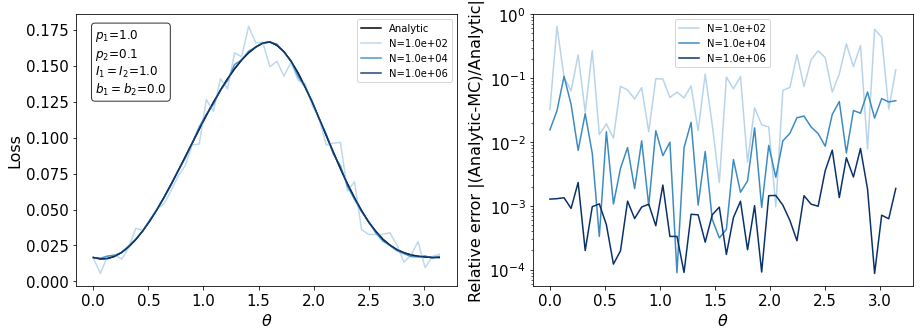

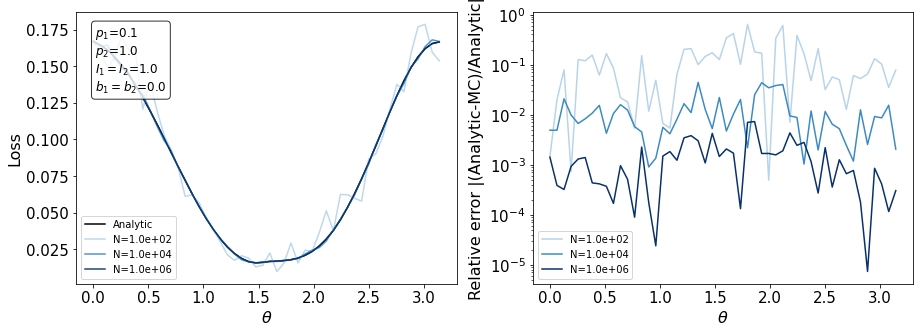

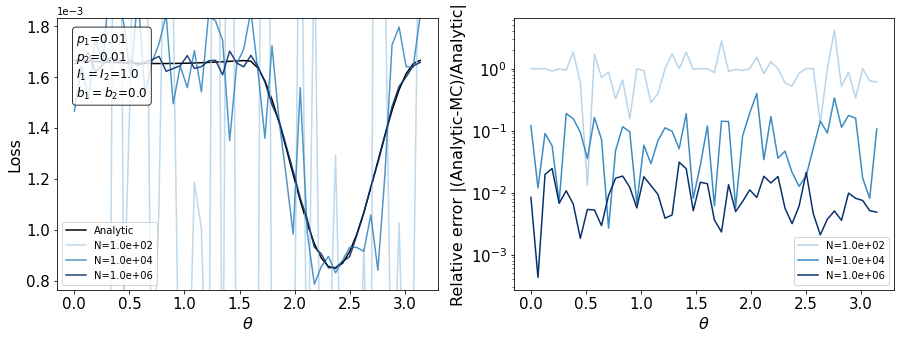

In [636]:
for j in range(len(p1_vals)):
    p1 = p1_vals[j]
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].plot(theta_vals,result_analytic_np[j,:],color='Black',label='Analytic')
    ax[0].set_xlabel(r"$\theta$",fontsize=16)
    ax[0].set_ylabel("Loss",fontsize=16)
    ax[0].tick_params(axis='both', labelsize=15)


    ax[1].set_xlabel(r"$\theta$",fontsize=16)
    ax[1].set_ylabel("Relative error |(Analytic-MC)/Analytic|",fontsize=16)
    ax[1].tick_params(axis='both', labelsize=15)

    ax[0].text(
        0.05, 0.95,
        f"$p_1$={p1}\n$p_2$={p2_vals[j]}\n$I_1=I_2$={I1}\n$b_1=b_2$={b1}",
        transform=ax[0].transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    colors = plt.cm.Blues(np.linspace(0.3, 1, 3))
    for i in range(len(N_sample_vals)):
        ax[0].plot(theta_vals,result_MC_np[j,i,:],color= colors[i],label=f'N={N_sample_vals[i]:.1e}',alpha=0.9)
        ax[1].plot(theta_vals,np.abs(result_MC_np[j,i,:]-result_analytic_np[j,:])/result_analytic_np[j,:],color= colors[i],label=f'N={N_sample_vals[i]:.1e}') 
        ax[1].set_yscale('log')

    ax[0].legend()
    ax[1].legend()
    
    if j==2:
        minloss = min(result_analytic_np[j,:])
        maxloss = max(result_analytic_np[j,:])
        ax[0].set_ylim(0.9* minloss, 1.1*maxloss)
        ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    plt.show()

**Observations from the MC validation:**

- The analytic formula matches Monte Carlo across all three regimes, with the three curves converging visibly as $N$ increases from $10^2$ to $10^6$.
- The statistical error scales like $1/\sqrt{N p}$, therefore convergence in this case requires $Np \gg 1$.
- As expected, the worst agreement (and the slowest convergence) occurs in the very sparse regime (run 3, $p_1 = p_2 = 0.01$). When $b_i = 0$, samples where both features are inactive contribute *exactly zero* to the loss (since $x'_i = \mathrm{ReLU}(0) = 0$), so the MC estimator is unbiased. At $N = 10^2$ and $p = 0.01$ we have $Np = 1$, explaining the large $\mathcal{O}(1)$ fluctuations. Conversely, for $N=10^{6}$ we have $Np = 10^4$, which matches the observed $\mathcal{O}(10^{-2})$ fluctuation around the mean. 


## 3. Phase Diagram 

### Leading-order phase boundary derivation

At leading order in sparsity the $D$ term is $O(p_1 p_2)$ and negligible, and the optimal biases can be found analytically. Evaluating the loss at the three candidate solutions gives:

**Feature 1 only** ($\theta = 0$, $b_1 = 0$, $b_2 = p_2/2$): the network stores feature 1 perfectly and pays the full reconstruction cost on the unrepresented feature 2,

$$E[\mathcal{L}]\big|_{\theta=0} = \frac{I_2 p_2}{3} + O(p^2).$$

**Feature 2 only** ($\theta = \pi/2$, $b_2 = 0$, $b_1 = p_1/2$): by symmetry,

$$E[\mathcal{L}]\big|_{\theta=\pi/2} = \frac{I_1 p_1}{3} + O(p^2).$$

**Superposition** ($\theta = 3\pi/4$, $b_1, b_2 \to 0^+$): both features are stored in an anti-podal pair. The ReLU separates them because feature 1 drives the pre-activation positive while feature 2 drives it negative. The leading-order loss is

$$E[\mathcal{L}]\big|_{\theta=3\pi/4} = \frac{I_1 p_1 + I_2 p_2}{12} + O(p^2).$$

The factor of $1/12$ versus $1/3$ reflects that superposition incurs only partial interference, not full loss of a feature.

**Phase boundaries.** Superposition beats $\theta = 0$ when

$$\frac{I_1 p_1 + I_2 p_2}{12} < \frac{I_2 p_2}{3} \quad \Longleftrightarrow \quad q_2 > \frac{q_1}{3},$$

and beats $\theta = \pi/2$ when

$$\frac{I_1 p_1 + I_2 p_2}{12} < \frac{I_1 p_1}{3} \quad \Longleftrightarrow \quad q_2 < 3\,q_1.$$

This gives the three-phase structure with boundaries at $q_2/q_1 \in \{1/3,\, 3\}$:

$$\theta^* = \begin{cases} 0 & q_2 < q_1/3 \\ 3\pi/4 & q_1/3 < q_2 < 3q_1 \\ \pi/2 & q_2 > 3q_1 \end{cases}$$

At finite $p_i$ the boundaries shift due to higher-order corrections in the $D$ term; the scan below traces this full dependence numerically. We also note that, as expected, the phase boundaries are symmetric under the exchange $1 \leftrightarrow 2$.

### Numerical method

The phase diagram is computed by optimising $E[\mathcal{L}]$ over a dense grid of $(\theta, b_1, b_2)$ at each of $40^3 = 64{,}000$ outer parameter points $(I_2, p_1, p_2)$, using vectorised NumPy broadcasting (no Python loops over grid points). Because $E[\mathcal{L}]$ scales linearly in $I_1$, we fix $I_1 = 1$ without loss of generality, reducing the parameter space from four dimensions to three.

For each outer point we:
1. Evaluate the loss on a grid of $22 \times 22 = 484$ bias pairs $(b_1, b_2)$ and $80$ values of $\theta$, all in a single batched call to `loss_batch`.
2. Track the $(\theta, b_1, b_2)$ triple that achieves the minimum loss.
3. Record $\theta^* \bmod \pi$ (since $\theta$ and $\theta + \pi$ give the same $w^T w$).

In [637]:
import time

# ── 3-D outer grid: fix I1=1, scan I2 ∈ [0.1, 10], p1/p2 ∈ [1e-3, 1] ───────
# Fixing I1=1 removes a redundant rescaling degree of freedom, so the phase
# depends only on q1 = p1  and  q2 = I2*p2.  With one fewer dimension we can
# use 20 points/axis for the same cost as the old 10^4 scan.
N_GRID  = 40
I2_vals = np.logspace(-1, 1, N_GRID)   # 0.1 … 10
p_vals  = np.logspace(-3, 0, N_GRID)   # 1e-3 … 1.0

I2g, p1g, p2g = np.meshgrid(I2_vals, p_vals, p_vals, indexing='ij')

# Flatten + trailing singleton for broadcasting against the bias axis
I1_f = np.ones((I2g.size, 1))      # I1 fixed at 1
I2_f = I2g.ravel()[:, None]        # (N_PT, 1)
p1_f = p1g.ravel()[:, None]
p2_f = p2g.ravel()[:, None]
N_PT = I1_f.shape[0]               # 20^3 = 8 000

# ── Bias grid: 22 × 22 = 484 (b1, b2) pairs ─────────────────────────────────
N_B1    = 22
b_vals  = np.linspace(-1.0, 0.7, N_B1)
B1g, B2g = np.meshgrid(b_vals, b_vals, indexing='ij')
b1_flat = B1g.ravel()[None, :]   # (1, N_B)
b2_flat = B2g.ravel()[None, :]
N_B     = b1_flat.shape[1]       # 484

# ── Scan over 80 θ values, vectorising over the full (N_PT × N_B) grid ──────
N_T        = 80
theta_grid = np.linspace(0.015, np.pi - 0.015, N_T)

best_L     = np.full(N_PT, np.inf)
best_theta = np.zeros(N_PT)
best_b1    = np.zeros(N_PT)
best_b2    = np.zeros(N_PT)

print(f"Vectorised scan: {N_T} θ values × ({N_PT:,} outer pts × {N_B} bias pairs)  …")
t_start = time.time()

for theta in theta_grid:
    # L shape: (N_PT, N_B)  —  broadcast: outer-grid dims × bias-grid dim
    L = loss_batch(theta, b1_flat, b2_flat, p1_f, p2_f, I1_f, I2_f)

    # Best bias pair for each outer-grid point at this theta
    min_L_here = L.min(axis=1)          # (N_PT,)
    best_b_idx = L.argmin(axis=1)       # (N_PT,)

    improved = min_L_here < best_L
    best_L     = np.where(improved, min_L_here,          best_L)
    best_theta = np.where(improved, theta,               best_theta)
    best_b1    = np.where(improved, b1_flat[0, best_b_idx], best_b1)
    best_b2    = np.where(improved, b2_flat[0, best_b_idx], best_b2)

elapsed = time.time() - t_start
print(f"Done in {elapsed:.1f} s")

df_scan = pd.DataFrame({
    'I1': 1.0,
    'I2': I2g.ravel(), 'p1': p1g.ravel(), 'p2': p2g.ravel(),
    'q1': p1g.ravel(),               # q1 = I1*p1 = p1  (I1=1)
    'q2': I2g.ravel()*p2g.ravel(),   # q2 = I2*p2
    'theta': best_theta % np.pi, 'b1': best_b1, 'b2': best_b2, 'loss': best_L,
})
# print(df_scan[['q1','q2','theta','b1','b2','loss']].describe().round(4))


Vectorised scan: 80 θ values × (64,000 outer pts × 484 bias pairs)  …
Done in 47.9 s


In [638]:
df_scan['lq1']  = np.round(np.log10(df_scan['q1']), 10)
df_scan['lq2']  = np.round(np.log10(df_scan['q2']), 10)

group_cols = ['lq1', 'lq2']
group_size = df_scan.groupby(group_cols)['theta'].transform('size')
df_scan['has_repeats'] = group_size > 1

df_no_repeats = df_scan[~df_scan['has_repeats']]
df_repeats = df_scan[(df_scan['has_repeats']) & (df_scan['q1']<1.0)  & (df_scan['q2']<10.0) & (df_scan['q2']>1e-4) ]

stats = df_repeats.groupby(['lq1','lq2'])['theta'].agg(['mean','std','count'])

### 3.1 Testing the $q_i$-collapse assumption

The scan produces a 3-D dataset over $(I_2, p_1, p_2)$. At leading order in $p_i$, the phase is predicted to depend only on the effective scarcities $q_i = I_i p_i$, collapsing this 3-D space onto a 2-D plane. We test that prediction directly: for each $(q_1, q_2)$ pair that is hit by multiple $(I_2, p_1, p_2)$ triples, we check whether all those triples give the same discrete phase.

The heatmap below shows the **phase agreement fraction** — the fraction of iso-$(q_1, q_2)$ points whose optimised $\theta^*$ falls in the same phase. Green ($= 1$) means the $q_i$-collapse holds perfectly; red ($< 1$) means different triples at the same $(q_1, q_2)$ disagree, marking where the leading-order approximation breaks down. The breakdown is concentrated near the phase boundaries and at large $q_i$ (large $p_i$), while the interiors of each phase remain clean. This motivates restricting to $\log_{10} q_1 < -1.5$ when plotting the phase diagram.

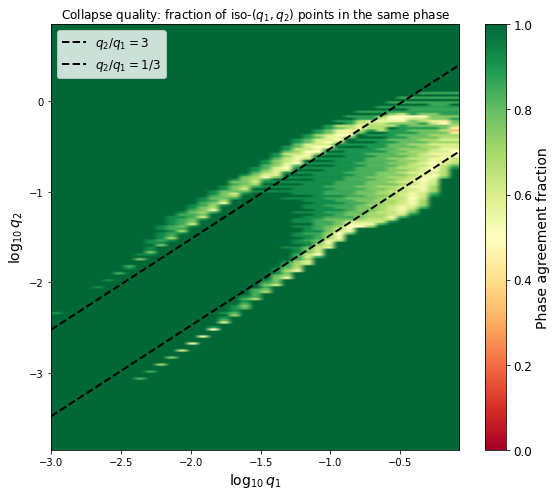

In [639]:
# ── Phase label: classify each θ* into one of three phases ──────────────────
# Boundaries at π/4 (between 0 and π/2) and 5π/8 (between π/2 and 3π/4)
def classify_phase(theta):
    if theta < np.pi / 4 or theta > 7 * np.pi / 8:
        return 'feat1'    # θ ≈ 0 or θ ≈ π  (same w^Tw)
    elif theta < 5 * np.pi / 8:
        return 'feat2'    # θ ≈ π/2
    else:
        return 'super'    # θ ≈ 3π/4

df_repeats = df_repeats.copy()
df_repeats['phase'] = df_repeats['theta'].apply(classify_phase)

# ── Agreement fraction: fraction of iso-(q1,q2) points sharing the modal phase
def agreement_fraction(phases):
    return phases.value_counts().iloc[0] / len(phases)

agree = (df_repeats
         .groupby(['lq1', 'lq2'])['phase']
         .apply(agreement_fraction)
         .reset_index(name='agreement'))

grid_agree = agree.pivot(index='lq2', columns='lq1', values='agreement')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    grid_agree,
    origin='lower', aspect='auto',
    cmap='RdYlGn', vmin=0, vmax=1,
    extent=[grid_agree.columns.min(), grid_agree.columns.max(),
            grid_agree.index.min(),   grid_agree.index.max()]
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Phase agreement fraction', fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel(r'$\log_{10} q_1$', fontsize=14)
ax.set_ylabel(r'$\log_{10} q_2$', fontsize=14)
ax.set_title(r'Collapse quality: fraction of iso-$(q_1,q_2)$ points in the same phase',
             fontsize=12)

q1_line = np.linspace(grid_agree.columns.min(), grid_agree.columns.max(), 200)
ax.plot(q1_line, q1_line + np.log10(3),   'k--', lw=2, label=r'$q_2/q_1 = 3$')
ax.plot(q1_line, q1_line + np.log10(1/3), 'k--', lw=2, label=r'$q_2/q_1 = 1/3$')
ax.legend(fontsize=12)
ax.set_ylim(grid_agree.index.min(), grid_agree.index.max())

plt.tight_layout()
plt.show()

### 3.2 Phase diagram in the $(q_1, q_2)$ plane

Restricting to the clean region $\log_{10} q_1 < -1.5$ (where the agreement fraction above is uniformly high), we plot the mean $\theta^*$ as a function of $(\log_{10} q_1,\, \log_{10} q_2)$. The three phases are clearly visible, and the leading-order boundary lines $q_2/q_1 \in \{1/3, 3\}$ pass accurately through the observed transitions.

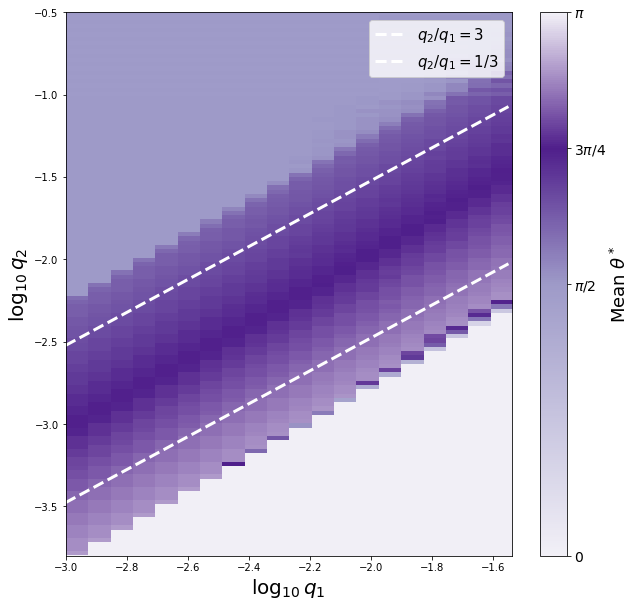

In [640]:
from matplotlib.colors import LinearSegmentedColormap

theta_0_color   = plt.cm.Purples(0.1)
theta_pi2_color = plt.cm.Purples(0.5)
theta_pi4_color = plt.cm.Purples(0.9)

cmap_cyclic = LinearSegmentedColormap.from_list('phases_cyclic', [
    (0.00, theta_0_color),    # θ = 0      : feat-1
    (0.50, theta_pi2_color),  # θ = π/2    : feat-2
    (0.75, theta_pi4_color),  # θ = 3π/4   : super
    (1.00, theta_0_color),    # θ = π      : feat-1 (same as 0)
])

q1_vals = np.linspace(-3, -1.55, 100)

sel = (stats.index.get_level_values('lq1') < -1.5)
theta_map = stats.loc[sel, 'mean']
grid = theta_map.reset_index().pivot(index='lq2', columns='lq1', values='mean')

plt.figure(figsize=(10, 10))
plt.imshow(
    grid,
    origin='lower',
    aspect='auto',
    cmap=cmap_cyclic,
    vmin=0, vmax=np.pi,
    extent=[grid.columns.min(), grid.columns.max(),
            grid.index.min(),   grid.index.max()]
)
cbar = plt.colorbar()
cbar.set_ticks([0, np.pi/2, 3*np.pi/4, np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
cbar.set_label(r'Mean $\theta^*$', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel(r'$\log_{10} q_1$', fontsize=20)
plt.ylabel(r'$\log_{10} q_2$', fontsize=20)
plt.ylim(-3.8, -0.5)

plt.plot(q1_vals, q1_vals + np.log10(3),   label=r'$q_2/q_1 = 3$',   color='white', linestyle='--', linewidth=3)
plt.plot(q1_vals, q1_vals + np.log10(1/3), label=r'$q_2/q_1 = 1/3$', color='white', linestyle='--', linewidth=3)

plt.legend(fontsize=15)
plt.show()


### Interpretation

The heatmap above shows $\theta^*$ in the $(\log_{10} q_1,\, \log_{10} q_2)$ plane. Three distinct phases are visible:

- **Dark / $\theta \approx 0$** (bottom-right triangle): feature 1 dominates. The network ignores feature 2 entirely.
- **Light / $\theta \approx \pi/2$** (top-left triangle): feature 2 dominates. The network ignores feature 1.
- **Intermediate / $\theta \approx 3\pi/4$** (diagonal band): the superposition phase. Both features share the single latent dimension in an anti-podal configuration: feature 1 activates the neuron positively, feature 2 activates it negatively, and the ReLU separates them at readout.

The two dashed white lines at $q_2/q_1 = 3$ and $q_2/q_1 = 1/3$ mark the predicted phase boundaries. They pass through the numerically observed phase transitions with high accuracy, confirming the analytical result.

**The key takeaway**: a single ReLU neuron can represent two sparse features simultaneously with a well-defined loss minimum, something that is impossible in the purely linear model.

### 3.3 Finite-$p$ corrections: phase boundaries in the $(p_1, p_2)$ plane

When $p_i$ is no longer negligible, the phase boundaries shift away from the leading-order lines $q_2/q_1 = \{1/3,\, 3\}$. To visualise this, we plot $\theta^*$ in the $(p_1, p_2)$ plane at six fixed values of $I_2$.

The dashed and dotted white lines show the leading-order predictions $p_2 = p_1/(3 I_2)$ and $p_2 = 3p_1/I_2$. At small $p_1, p_2$ (bottom-left of each panel) the observed boundaries align well with these lines. At larger $p_1, p_2$ they deviate, confirming that $q_i = I_i p_i$ governs the phase only in the sparse limit; the combination $I_2 p_i$ controls the size of the correction.

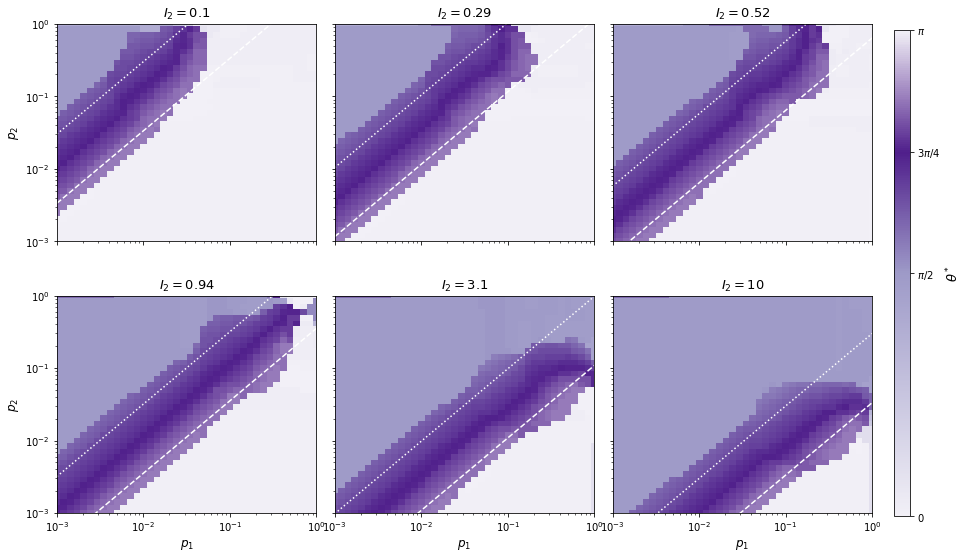

In [641]:
from matplotlib.colors import LinearSegmentedColormap

# Cyclic colormap: θ=0 and θ=π share the same colour (both are feat-1)
# key points at normalised positions 0, 0.5 (=π/2, feat-2), 0.75 (=3π/4, super), 1.0

# phases_colors = plt.cm.Greens(np.linspace(0.3, 1, 3))

theta_0_color = plt.cm.Purples(0.1)

theta_pi2_color = plt.cm.Purples(0.5)

theta_pi4_color = plt.cm.Purples(0.9)

cmap_cyclic = LinearSegmentedColormap.from_list('phases_cyclic', [
    (0.00, theta_0_color),   # θ = 0      : feat-1  (dark navy)
    (0.50, theta_pi2_color),   # θ = π/2    : feat-2  (purple)
    (0.75, theta_pi4_color),   # θ = 3π/4   : super   (orange)
    (1.00, theta_0_color),   # θ = π      : feat-1  (same dark navy)
])

def median_filter_2d(arr, size=3):
    """Pure-numpy 2D median filter with edge-padding."""
    pad = size // 2
    padded = np.pad(arr, pad, mode='edge')
    h, w = arr.shape
    out = np.empty_like(arr)
    for i in range(h):
        for j in range(w):
            out[i, j] = np.median(padded[i:i+size, j:j+size])
    return out

I2_grid    = np.logspace(-1, 1, 40)
I2_targets = [0.1, 0.3, 0.5, 1.0, 3.0, 10.0]
I2_chosen  = [I2_grid[np.argmin(np.abs(I2_grid - t))] for t in I2_targets]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True, sharex=True)
axes_flat  = axes.flatten()

p1_line = np.logspace(-3, 0, 300)

for ax, I2_val in zip(axes_flat, I2_chosen):
    subset = df_scan[np.isclose(df_scan['I2'], I2_val, rtol=1e-6)]
    grid   = subset.pivot(index='p2', columns='p1', values='theta')

    # wrap θ ≈ π back to feat-1 (same phase as θ = 0); cyclic cmap makes this seamless
    theta_vals = np.where(grid.values > 7*np.pi/8, 0.0, grid.values)
    theta_vals = median_filter_2d(theta_vals, size=3)

    im = ax.pcolormesh(grid.columns, grid.index, theta_vals,
        cmap=cmap_cyclic, vmin=0, vmax=np.pi, shading='auto')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.plot(p1_line, p1_line / (3 * I2_val), 'w--', lw=1.5)
    ax.plot(p1_line, 3 * p1_line / I2_val,   'w:',  lw=1.5)
    ax.set_xlim(grid.columns.min(), grid.columns.max())
    ax.set_ylim(grid.index.min(),   grid.index.max())
    ax.set_title(f'$I_2 = {I2_val:.2g}$', fontsize=13)

for ax in axes[1, :]:
    ax.set_xlabel(r'$p_1$', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$p_2$', fontsize=12)

fig.subplots_adjust(right=0.88, wspace=0.07, hspace=0.25)
cbar_ax = fig.add_axes([0.90, 0.12, 0.015, 0.75])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_ticks([0, np.pi/2, 3*np.pi/4, np.pi])
cbar.set_ticklabels([r'$0$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
cbar.set_label(r'$\theta^*$', fontsize=13)
plt.show()


### Interpretation

When $I_2 \ll 1$, for sufficiently large values of $p_1$ the $\theta=0$ phase expands beyond the region predicted at leading order; since feature 2's contribution to the loss is suppressed, feature 1's reconstruction is still preferred in those regions. As $I_2$ approaches unity, the phase space becomes symmetric and mostly agrees with the leading order prediction. For $I_2 \gg 1$, for sufficiently large values of $p_2$ the $\theta=\pi/2$ phase expands beyond the region predicted at leading order; since feature 1's contribution to the loss is suppressed (compared to feature 2), feature 2's reconstruction is still preferred in those regions.

---

## Summary

This notebook derives and verifies a closed-form theory of superposition in a nonlinear toy autoencoder.

**What was shown:**

1. **Exact analytical formula.** The expected loss $E[\mathcal{L}]$ can be computed in closed form for any $(\theta, b_1, b_2, p_1, p_2, I_1, I_2)$ using six auxiliary integrals ($F_n$, $G$, $\mathcal{F}_n$, $\mathcal{H}$, $\mathcal{G}$) that arise from integrating ReLU power laws over uniform distributions.

2. **Monte Carlo validation.** The formula agrees with empirical averages at $O(N^{-1/2})$ convergence across all tested parameter regimes, including both dense and extremely sparse ($p \sim 10^{-2}$) settings. In the very sparse regime convergence requires $Np \gg 1$; the analytical formula is most valuable precisely there.

3. **Three-phase structure.** Numerical minimisation over a $40^3$ parameter grid reveals three phases. At leading order in sparsity ($p_i \ll 1$), the boundaries are governed by the effective scarcity $q_i = I_i p_i$:
   - $\theta^* = 0$ (feature 1 only) when $q_2 < q_1/3$
   - $\theta^* = 3\pi/4$ (**superposition**) when $q_1/3 < q_2 < 3q_1$
   - $\theta^* = \pi/2$ (feature 2 only) when $q_2 > 3q_1$

4. **Effective scarcity $q_i = I_i p_i$ as the key combination.** The phase boundaries at leading order depend on $I_i$ and $p_i$ only through their product $q_i$. This means a rare but important feature and a moderately common but less important one are interchangeable: what matters is not sparsity or importance individually, but the feature's effective contribution to the loss. This identification goes beyond simply reproducing the Elhage et al. phase diagram: it collapses the 3-D parameter space $( I_2/I_1, p_1, p_2)$ onto 2-D, and we quantify numerically how and where this collapse breaks down at finite $p_i$ (Sections 3.2--3.3). The breakdown is localised to a strip near the phase boundaries and widens as $p_i$ increases, with the deviation controlled by $I_2 p_i$ corrections to the leading-order boundary.

**Contrast with the linear model.** The companion notebook `linear_superposition_toy_model.ipynb` proves that the same architecture without ReLU has no superposition phase: the non-trivial critical point $\theta^*$ is always a saddle. The ReLU is therefore the minimal ingredient needed for superposition to emerge.

**Further directions.** Natural extensions include: $n > 2$ features, $m > 1$ latent dimensions, non-uniform input distributions, and the effect of gradient-based training dynamics on which phase is reached.

---
*Code depends only on `numpy`, `pandas`, and `matplotlib`.*
